# Notebook 1b: MIMU 特征提取 (2s 短窗口)

将窗口从 8s 缩短至 2s 以匹配波比跳单动作阶段的物理持续时间 (~2-4s/周期)。
特征调整: 增加偏度和峰度(反映冲击性), 移除短窗口下不稳定的谱熵和谱平坦度。

**输出产物**: `artifacts/mimu_features_shortwin.pkl`

In [1]:
import pickle
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

PROJECT_ROOT = Path(r"D:\data\PPG_HeartRate\Algorithm\outline-PPGtoHR")
DATA_DIR = PROJECT_ROOT / "docs" / "research" / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "docs" / "research" / "artifacts"

sns.set_style("whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

EXERCISES = {
    "jump_rope":     {"prefix": "tiaosheng", "label": "跳绳",     "complexity": "simple"},
    "arm_curl":      {"prefix": "wanju",    "label": "手臂弯举", "complexity": "simple"},
    "push_up":       {"prefix": "fuwo",     "label": "俯卧撑",   "complexity": "simple"},
    "jumping_jack":  {"prefix": "kaihe",    "label": "开合跳",   "complexity": "simple"},
    "burpee":        {"prefix": "bobi",     "label": "波比跳",   "complexity": "complex"},
}
PREFIX_MAP = {info["prefix"]: name for name, info in EXERCISES.items()}

FS = 100
WIN_SEC = 2
STEP_SEC = 0.5
WIN_SAMPLES = WIN_SEC * FS
STEP_SAMPLES = int(STEP_SEC * FS)
MOTION_THRESHOLD = 0.05

MIMU_COLUMN_MAP = {
    "AccX(g)": "AccX", "AccY(g)": "AccY", "AccZ(g)": "AccZ",
    "GyroX(dps)": "GyroX", "GyroY(dps)": "GyroY", "GyroZ(dps)": "GyroZ",
}
MIMU_CHANNELS = ["AccX", "AccY", "AccZ", "GyroX", "GyroY", "GyroZ"]


def discover_csv_files(data_dir):
    files = []
    for csv_file in sorted(data_dir.glob("multi_*.csv")):
        if csv_file.stem.endswith("_ref"):
            continue
        m = re.match(r"multi_([a-z]+)", csv_file.stem)
        if not m:
            continue
        prefix = m.group(1)
        exercise = PREFIX_MAP.get(prefix)
        if exercise is None:
            continue
        files.append((csv_file, exercise, csv_file.stem))
    return files


all_files = discover_csv_files(DATA_DIR)
print(f"窗口配置: {WIN_SEC}s / {STEP_SEC}s 步长 ({WIN_SAMPLES} 采样点/窗口)")
print(f"\n数据文件:")
for csv_f, name, stem in all_files:
    label = EXERCISES[name]["label"]
    tag = "[复杂]" if EXERCISES[name]["complexity"] == "complex" else "[简单]"
    print(f"  {tag} {label}: {csv_f.name}")

窗口配置: 2s / 0.5s 步长 (200 采样点/窗口)

数据文件:
  [复杂] 波比跳: multi_bobi1.csv
  [复杂] 波比跳: multi_bobi2.csv
  [简单] 俯卧撑: multi_fuwo1.csv
  [简单] 俯卧撑: multi_fuwo2.csv
  [简单] 开合跳: multi_kaihe1.csv
  [简单] 开合跳: multi_kaihe2.csv
  [简单] 跳绳: multi_tiaosheng2.csv
  [简单] 跳绳: multi_tiaosheng3.csv
  [简单] 手臂弯举: multi_wanju1.csv
  [简单] 手臂弯举: multi_wanju2.csv


## 1. 特征提取函数

75 维特征 (与原版同维度, 调整特征组成):
- 6 通道各 9 时域 (mean/std/min/max/range/energy/zcr/skewness/kurtosis) + 1 频域 (dominant_freq) = 60
- acc_mag / gyro_mag 各 4 维 = 8
- 跨通道相关系数 7 维
- 总计 75 维

**与原版差异**: skewness + kurtosis 替换 spectral_entropy + spectral_flatness; 短窗口下频率分辨率降低, 谱类特征不稳定

In [2]:
TIME_FEATURES = ["mean", "std", "min", "max", "range", "energy", "zcr", "skewness", "kurtosis"]
FREQ_FEATURES = ["dominant_freq"]
MAG_FEATURES = ["mean", "std", "energy", "dominant_freq"]


def extract_time_domain_features(signal):
    return {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "min": np.min(signal),
        "max": np.max(signal),
        "range": np.max(signal) - np.min(signal),
        "energy": np.mean(signal ** 2),
        "zcr": np.sum(np.diff(np.sign(signal)) != 0) / (len(signal) - 1),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
    }


def extract_freq_domain_features(signal, fs=100):
    nperseg = min(len(signal), 256)
    freqs, psd = welch(signal, fs=fs, nperseg=nperseg)
    non_dc = psd[1:]
    dominant_freq = freqs[1:][np.argmax(non_dc)] if len(non_dc) > 0 and np.max(non_dc) > 0 else 0.0
    return {"dominant_freq": dominant_freq}


def build_feature_names():
    names = []
    for ch in MIMU_CHANNELS:
        names.extend(f"{ch}_{f}" for f in TIME_FEATURES)
        names.extend(f"{ch}_{f}" for f in FREQ_FEATURES)
    for mag_name in ["acc_mag", "gyro_mag"]:
        names.extend(f"{mag_name}_{f}" for f in MAG_FEATURES)
    names.extend(["corr_acc_gyro"])
    names.extend(["corr_AccX_AccY", "corr_AccX_AccZ", "corr_AccY_AccZ"])
    names.extend(["corr_GyroX_GyroY", "corr_GyroX_GyroZ", "corr_GyroY_GyroZ"])
    return names


FEATURE_NAMES = build_feature_names()
print(f"特征维度: {len(FEATURE_NAMES)} (时域 {len(TIME_FEATURES)}/ch + 频域 {len(FREQ_FEATURES)}/ch)")


def extract_window_features(accx, accy, accz, gyrox, gyroy, gyroz, fs=100):
    features = []
    for sig in [accx, accy, accz, gyrox, gyroy, gyroz]:
        td = extract_time_domain_features(sig)
        fd = extract_freq_domain_features(sig, fs)
        features.extend(td[f] for f in TIME_FEATURES)
        features.extend(fd[f] for f in FREQ_FEATURES)

    acc_mag = np.sqrt(accx**2 + accy**2 + accz**2)
    gyro_mag = np.sqrt(gyrox**2 + gyroy**2 + gyroz**2)

    for mag in [acc_mag, gyro_mag]:
        td = extract_time_domain_features(mag)
        fd = extract_freq_domain_features(mag, fs)
        features.extend([td["mean"], td["std"], td["energy"], fd["dominant_freq"]])

    def safe_corr(a, b):
        return np.corrcoef(a, b)[0, 1] if np.std(a) != 0 and np.std(b) != 0 else 0.0

    features.append(safe_corr(acc_mag, gyro_mag))
    features.append(safe_corr(accx, accy))
    features.append(safe_corr(accx, accz))
    features.append(safe_corr(accy, accz))
    features.append(safe_corr(gyrox, gyroy))
    features.append(safe_corr(gyrox, gyroz))
    features.append(safe_corr(gyroy, gyroz))

    return np.array(features, dtype=float)

特征维度: 75 (时域 9/ch + 频域 1/ch)


In [3]:
def extract_features_for_file(csv_path):
    raw = pd.read_csv(csv_path, encoding="utf-8-sig")
    rename_map = {k: v for k, v in MIMU_COLUMN_MAP.items() if k in raw.columns}
    df = raw.rename(columns=rename_map)
    if "Time_s" not in df.columns:
        if "Time(s)" in raw.columns:
            df["Time_s"] = raw["Time(s)"]
        else:
            df["Time_s"] = np.arange(len(df), dtype=float) / float(FS)

    n_samples = len(df)
    start_idx = int(1.0 * FS)
    buffer_samples = int(10.0 * FS)
    end_idx = n_samples - buffer_samples

    records = []
    skipped = 0
    for win_start in range(start_idx, end_idx - WIN_SAMPLES + 1, STEP_SAMPLES):
        win_end = win_start + WIN_SAMPLES
        window_time = df["Time_s"].iloc[win_start]
        accx = df["AccX"].iloc[win_start:win_end].to_numpy()
        accy = df["AccY"].iloc[win_start:win_end].to_numpy()
        accz = df["AccZ"].iloc[win_start:win_end].to_numpy()
        gyrox = df["GyroX"].iloc[win_start:win_end].to_numpy()
        gyroy = df["GyroY"].iloc[win_start:win_end].to_numpy()
        gyroz = df["GyroZ"].iloc[win_start:win_end].to_numpy()

        acc_mag = np.sqrt(accx**2 + accy**2 + accz**2)
        if np.std(acc_mag) <= MOTION_THRESHOLD:
            skipped += 1
            continue

        feat_vec = extract_window_features(accx, accy, accz, gyrox, gyroy, gyroz, FS)
        records.append({"window_time": window_time, "features": feat_vec})
    return pd.DataFrame(records), skipped


print(f"开始批量提取特征 (窗口={WIN_SEC}s, 步长={STEP_SEC}s, 仅运动段)...")
all_records = []
for csv_f, name, stem in all_files:
    info = EXERCISES[name]
    print(f"  处理: {csv_f.name} ...", end=" ")
    try:
        df_feats, n_skip = extract_features_for_file(csv_f)
        df_feats["exercise"] = name
        df_feats["exercise_label"] = info["label"]
        df_feats["complexity"] = info["complexity"]
        df_feats["file_name"] = stem
        all_records.append(df_feats)
        print(f"{len(df_feats)} 运动窗口 (跳过 {n_skip} 静息)")
    except Exception as e:
        print(f"错误: {e}")

df_all = pd.concat(all_records, ignore_index=True)
print(f"\n总计: {len(df_all)} 个运动窗口, 来自 {df_all['file_name'].nunique()} 个文件")
print("\n各运动类型窗口统计:")
print(df_all.groupby(["complexity", "exercise_label"]).size().to_string())

开始批量提取特征 (窗口=2s, 步长=0.5s, 仅运动段)...
  处理: multi_bobi1.csv ... 107 运动窗口 (跳过 338 静息)
  处理: multi_bobi2.csv ... 103 运动窗口 (跳过 344 静息)
  处理: multi_fuwo1.csv ... 24 运动窗口 (跳过 365 静息)
  处理: multi_fuwo2.csv ... 23 运动窗口 (跳过 365 静息)
  处理: multi_kaihe1.csv ... 127 运动窗口 (跳过 319 静息)
  处理: multi_kaihe2.csv ... 121 运动窗口 (跳过 319 静息)
  处理: multi_tiaosheng2.csv ... 120 运动窗口 (跳过 326 静息)
  处理: multi_tiaosheng3.csv ... 107 运动窗口 (跳过 330 静息)
  处理: multi_wanju1.csv ... 125 运动窗口 (跳过 265 静息)
  处理: multi_wanju2.csv ... 121 运动窗口 (跳过 269 静息)

总计: 978 个运动窗口, 来自 10 个文件

各运动类型窗口统计:
complexity  exercise_label
complex     波比跳               210
simple      俯卧撑                47
            开合跳               248
            手臂弯举              246
            跳绳                227


In [4]:
X = np.stack(df_all["features"].values)
y = df_all["exercise"].values
labels = df_all["exercise_label"].values

nan_mask = ~np.isfinite(X)
if nan_mask.any():
    col_medians = np.nanmedian(X, axis=0)
    for j in range(X.shape[1]):
        mask = nan_mask[:, j]
        X[mask, j] = col_medians[j] if np.isfinite(col_medians[j]) else 0.0
    print(f"已修复 {nan_mask.sum()} 个 NaN/Inf 值")

print(f"特征矩阵: {X.shape}")
print(f"标签分布: {dict(zip(*np.unique(y, return_counts=True)))}")

simple_mask = df_all["complexity"].values == "simple"
print(f"\n训练集 (简单运动): {simple_mask.sum()} 个窗口")
for cls in EXERCISES:
    if EXERCISES[cls]["complexity"] != "simple":
        continue
    n = (y == cls).sum()
    print(f"  {EXERCISES[cls]['label']}: {n} 窗口")

特征矩阵: (978, 75)
标签分布: {'arm_curl': np.int64(246), 'burpee': np.int64(210), 'jump_rope': np.int64(227), 'jumping_jack': np.int64(248), 'push_up': np.int64(47)}

训练集 (简单运动): 768 个窗口
  跳绳: 227 窗口
  手臂弯举: 246 窗口
  俯卧撑: 47 窗口
  开合跳: 248 窗口


## 2. 可行性检查: PCA & t-SNE

所有数据均为运动段窗口。量化指标: Silhouette score (>0.5 好, 0.25-0.5 中, <0.25 差)

PCA 方差: PC1=0.343, PC2=0.182
Silhouette (全部运动窗口): 0.364


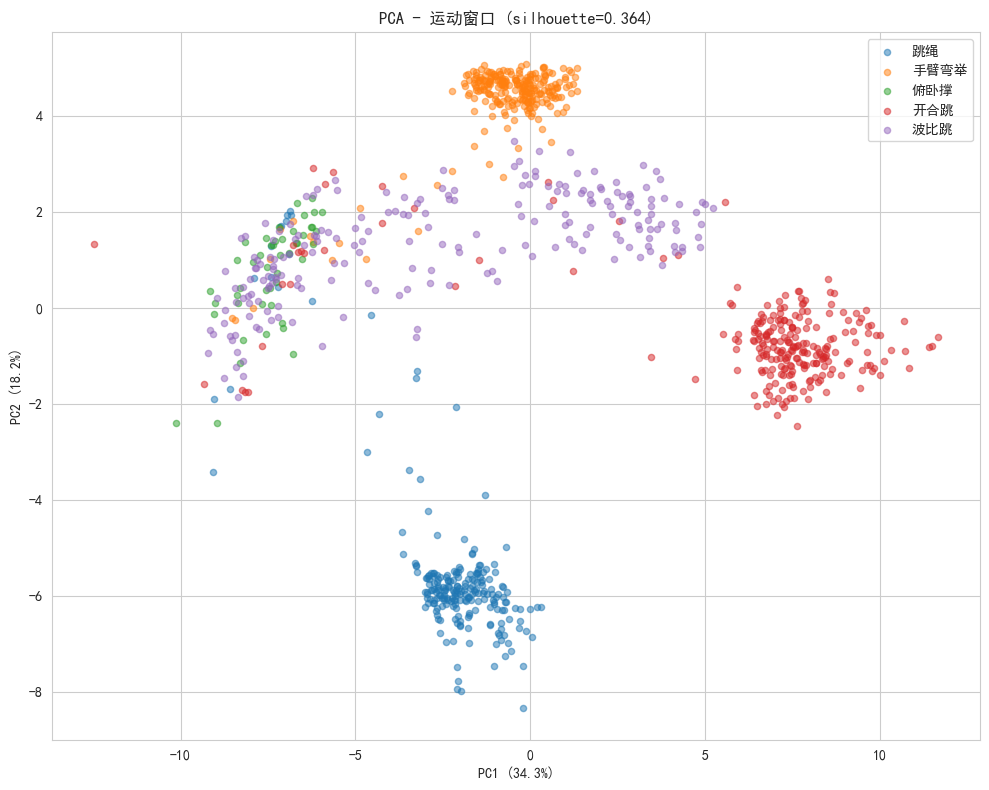

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
sil_all = silhouette_score(X_scaled, y)
print(f"PCA 方差: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Silhouette (全部运动窗口): {sil_all:.3f}")

fig, ax = plt.subplots(figsize=(10, 8))
for name in EXERCISES:
    mask = y == name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=EXERCISES[name]["label"], alpha=0.5, s=20)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"PCA - 运动窗口 (silhouette={sil_all:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

d:\Anaconda\envs\ppg-hr\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


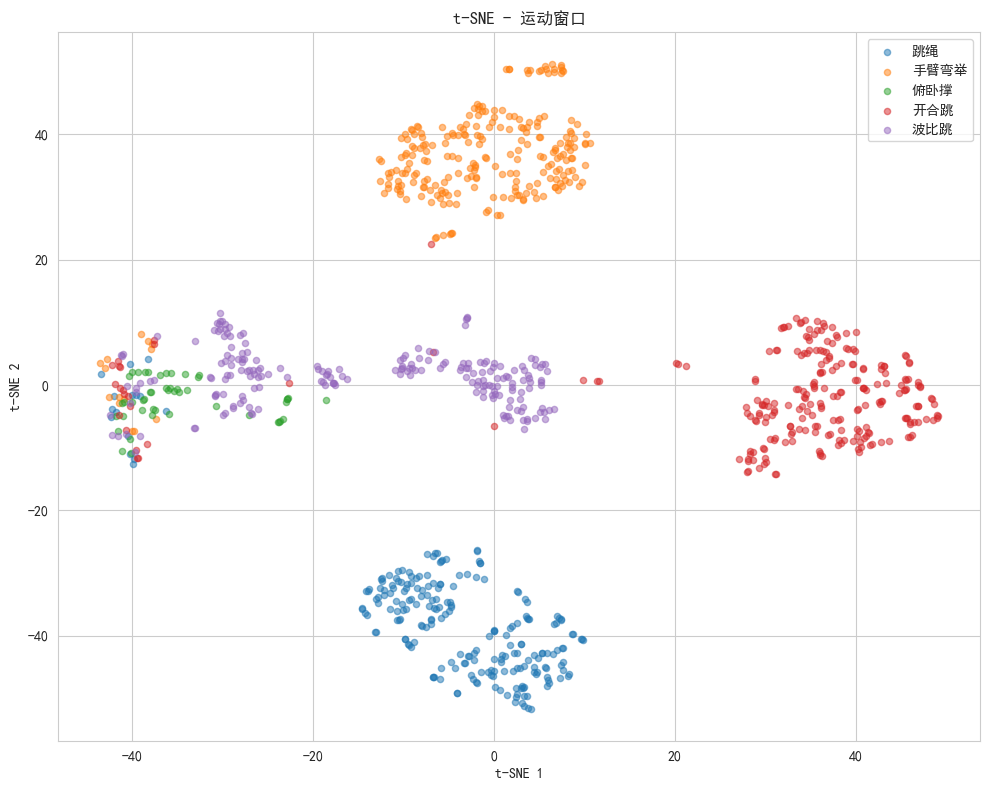

[训练集 = 简单运动] Silhouette: 0.481


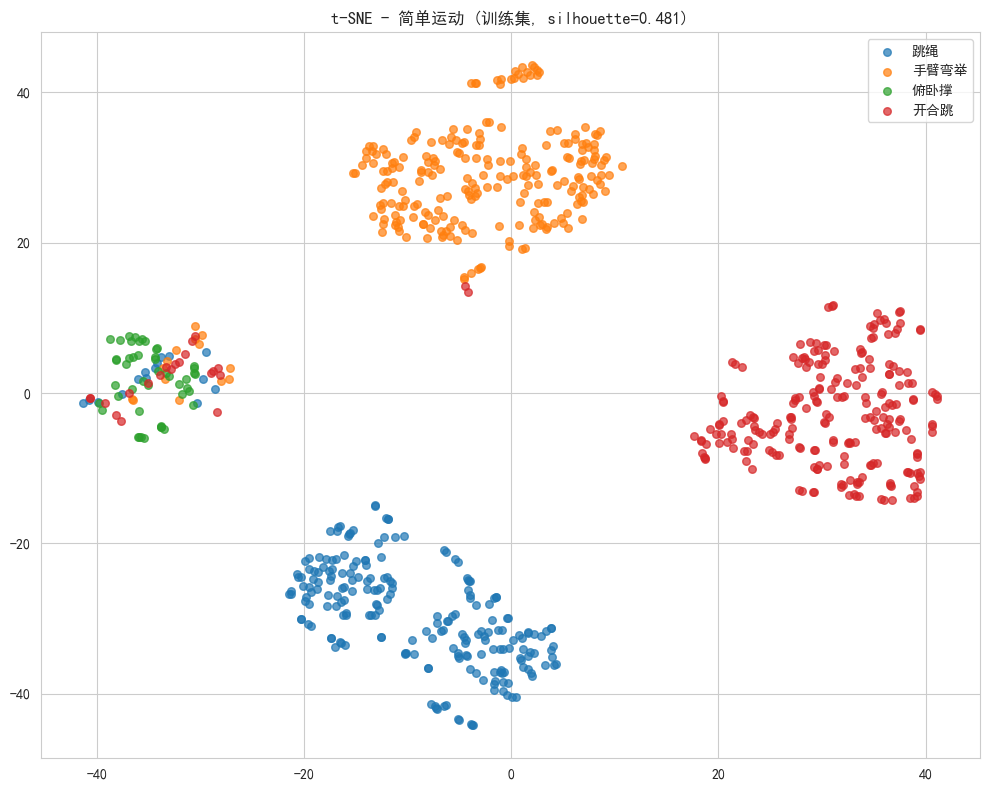

In [6]:
perp = min(30, min(np.unique(y, return_counts=True)[1]) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=max(5, perp))
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for name in EXERCISES:
    mask = y == name
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=EXERCISES[name]["label"], alpha=0.5, s=20)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE - 运动窗口")
ax.legend()
plt.tight_layout()
plt.show()

# 训练集可分性
X_train_vis = X_scaled[simple_mask]
y_train_vis = y[simple_mask]
sil_train = silhouette_score(X_train_vis, y_train_vis)
print(f"[训练集 = 简单运动] Silhouette: {sil_train:.3f}")

perp_t = min(30, min(np.unique(y_train_vis, return_counts=True)[1]) - 1)
tsne_train = TSNE(n_components=2, random_state=42, perplexity=max(5, perp_t))
X_tsne_train = tsne_train.fit_transform(X_train_vis)

fig, ax = plt.subplots(figsize=(10, 8))
for name in EXERCISES:
    if EXERCISES[name]["complexity"] != "simple":
        continue
    mask = y_train_vis == name
    ax.scatter(X_tsne_train[mask, 0], X_tsne_train[mask, 1],
               label=EXERCISES[name]["label"], alpha=0.7, s=30)
ax.set_title(f"t-SNE - 简单运动 (训练集, silhouette={sil_train:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

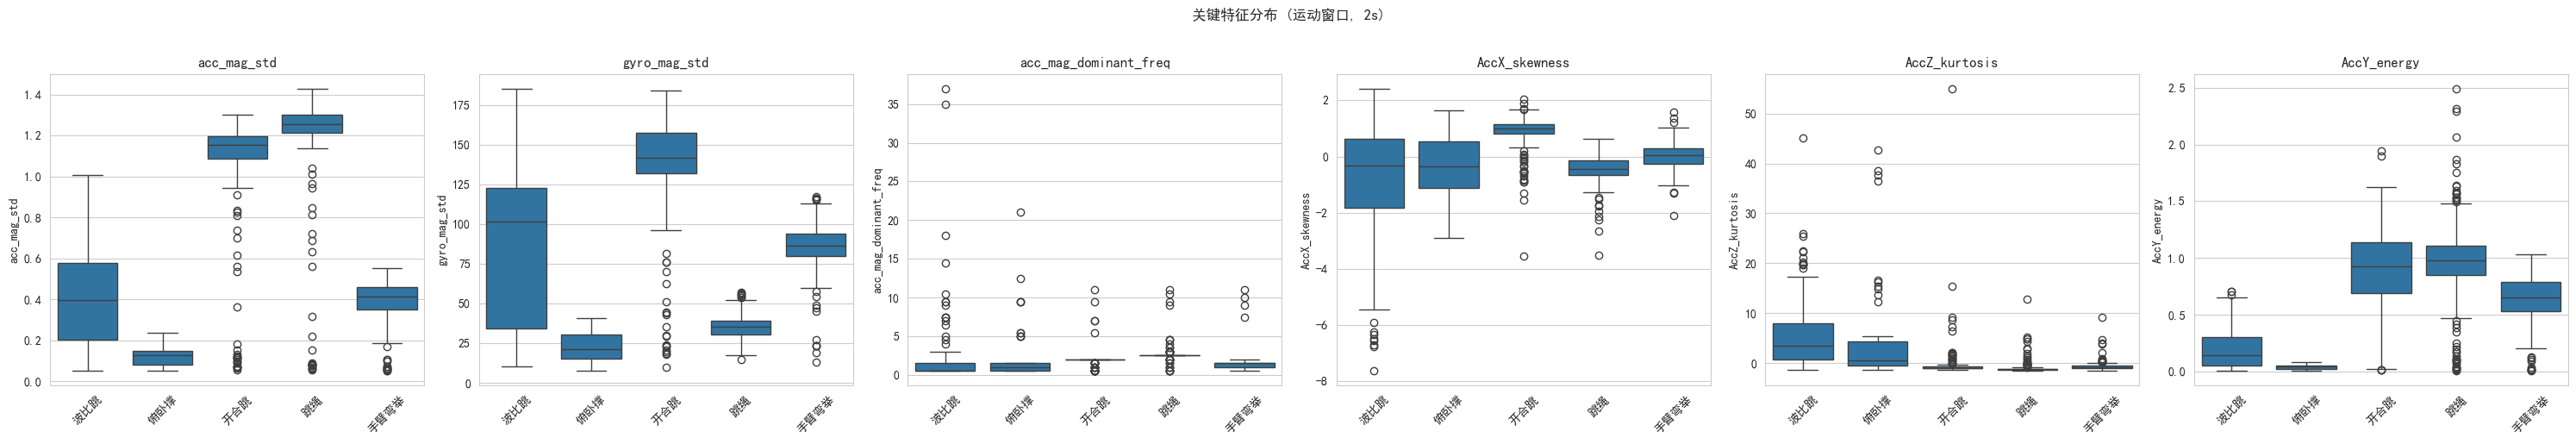

In [7]:
df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat["exercise_label"] = labels

key_features = ["acc_mag_std", "gyro_mag_std", "acc_mag_dominant_freq",
                "AccX_skewness", "AccZ_kurtosis", "AccY_energy"]
existing = [f for f in key_features if f in df_feat.columns]

fig, axes = plt.subplots(1, len(existing), figsize=(5 * len(existing), 5))
if len(existing) == 1:
    axes = [axes]
for ax, feat_name in zip(axes, existing):
    sns.boxplot(data=df_feat, x="exercise_label", y=feat_name, ax=ax)
    ax.set_title(feat_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("关键特征分布 (运动窗口, 2s)", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
output_path = ARTIFACTS_DIR / "mimu_features_shortwin.pkl"
save_data = {
    "df": df_all[["window_time", "exercise", "exercise_label", "complexity",
                   "file_name", "features"]],
    "X": X,
    "y": y,
    "labels": labels,
    "feature_names": FEATURE_NAMES,
    "win_sec": WIN_SEC,
    "step_sec": STEP_SEC,
}
with open(output_path, "wb") as f:
    pickle.dump(save_data, f)
print(f"已保存到: {output_path}")
print(f"  特征维度: {X.shape[1]}, 运动窗口数: {X.shape[0]}")

已保存到: D:\data\PPG_HeartRate\Algorithm\outline-PPGtoHR\docs\research\artifacts\mimu_features_shortwin.pkl
  特征维度: 75, 运动窗口数: 978
